In [1]:
%load_ext autoreload
%autoreload 2

# Standard library
import os
import tempfile

# Numerical computing
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Single-cell analysis
import scanpy as sc
import matplotlib.pyplot as plt

# R interface — used to call Nebula (an R package) from Python
import rpy2.robjects as ro

# Load environment variables from .env (e.g. path to the Nebula shell script)
from dotenv import load_dotenv
load_dotenv()

# Project utility modules
from utils import preprocessing
from utils import DEG

%matplotlib inline

# Path to the shell script that distributes Nebula gene chunks across cores
PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

# Config

In [2]:
### Download bican data from macosko bcujet
    # gs://macosko_data/leematth/sharing/Striatum_Zones_Paper/Updated_Objects/Full_Objects/STR_D1_Matrix_MSN.h5ad
# reduce size

bican = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/BICAN/STR_D1_Matrix_MSN.h5ad", backed="r")

bican

AnnData object with n_obs × n_vars = 539427 × 32632 backed at '/home/gdallagl/myworkdir/XDP/data/BICAN/STR_D1_Matrix_MSN.h5ad'
    obs: 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'age', 'pmi_hr', 'imputed_sex', 'toxicology_report_complete', 'mmc_neighborhood_name', 'mmc_neighborhood_bootstrapping_probability', 'mmc_class_name', 'mmc_class_bootstrapping_probability', 'mmc_subclass_name', 'mmc_subclass_bootstrapping_probability', 'mmc_group_name', 'mmc_group_bootstrapping_probability', 'mmc_cluster_name', 'mmc_cluster_bootstrapping_probability', 'neuropath_diagnosis', 'village', 'brain_region_abbreviation', 'is_primary_data', 'donor_id', 'n_counts', 'merge_step_6'

In [11]:
obs = bican.obs.copy()

obs["pct_mt"].corr(obs["age"], method="spearman")

bican.var.index.str.startswith("ENSG").sum()

obs["merge_step_6"]
obs["donor_id"].unique()

['MS652464', 'MD6571', 'MS323252', 'MD6666', 'MS272264', ..., 'MLS09843', 'MS428839', 'MS452564', 'MS44220', 'PT14073']
Length: 191
Categories (191, object): ['MD6366', 'MD6417', 'MD6424', 'MD6429', ..., 'UMBEB24013', 'UMBEB24053', 'UMBEB24113', 'UMBEB24130']

In [15]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BICAN_PATH  = "/home/gdallagl/myworkdir/XDP/data/BICAN/STR_D1_Matrix/d1_cleaner_v3_raw_dv_wm_labeled.h5ad"
SAVE_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula"
os.makedirs(SAVE_FOLDER, exist_ok=True)

# ── obs column names in BICAN (set once, used everywhere) ──────────────────────
SAMPLE_VARIABLE  = "donor_id"      # unique donor / sample identifier
AGE              = "age"           # donor age in years (continuous covariate)
ZONE_COL         = "zone"          # spatial zone label (integer 1-6)
LIBRARY_SIZE_COL = "total_counts"  # total UMI per cell; Nebula uses log(this) as offset
SEX_COL          = "sex"           # donor sex (encoded as 0/1 if stored as string)
PC_COLS          = ["PC1", "PC2", "PC3", "PC4", "PC5"]  # SNP-derived PCs; control for genetic ancestry

# ── Thresholds ─────────────────────────────────────────────────────────────────
REF_ZONE           = 1     # reference zone for dummy encoding (all other zones compared to this)
MIN_CELLS_PER_ZONE = 30    # drop a (donor, zone) pair if fewer than this many cells
MIN_CELLS_GENE     = 50    # drop a gene if expressed in fewer than this many cells across the whole dataset
MIN_COUNTS_GENE    = 100   # drop a gene if its total count is below this
DR_THR             = 0.05   # a gene is "lowly expressed" if mean detection rate < this threshold

# Load BICAN

In [16]:
# Load the BICAN D1 Matrix AnnData from disk
bican = sc.read_h5ad(BICAN_PATH)

# Rename obs columns to the standard names defined in Config
bican.obs = bican.obs.rename(columns={
    "merge_step_6": ZONE_COL,         # ATTENTION; this is final col deifned by matthiew
    "n_counts":     LIBRARY_SIZE_COL, # total UMI counts per cell
    "imputed_sex":  SEX_COL,          # computationally inferred sex
})

# Sanity check: print basic dataset dimensions and ranges
print(bican)
print(f"Donors : {bican.obs[SAMPLE_VARIABLE].nunique()}")
print(f"Age    : {bican.obs[AGE].min():.0f}–{bican.obs[AGE].max():.0f} years")
print(f"Zones  : {sorted(bican.obs[ZONE_COL].unique())}")

# Replace .X with the raw integer counts stored in the 'counts' layer
# Nebula requires raw counts — not normalized or log-transformed values
bican.X = bican.layers["counts"].copy()

AnnData object with n_obs × n_vars = 206571 × 38100
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scpred_caudate_spn_en_max_prob', 'scpred_caudate_spn_mp', 'scpred_caudate_spn_mp_max_prob', 'scpred_c

# Filter bad genes

In [17]:
# Prefixes that identify genes adding technical noise or lacking reliable annotations
BAD_PREFIXES = (
    "MT-", "MTRNR",       # mitochondrial — elevated in damaged / low-quality cells
    "RPL", "RPS",         # ribosomal proteins — dominate counts, not informative here
    "HBB", "HBA", "HBG",  # hemoglobin — blood contamination
    "HBD", "HBE", "HBZ",
    "ENSG",               # raw Ensembl IDs — no gene symbol assigned
    "LINC",               # long intergenic non-coding RNAs — poorly characterized
)

# Put all gene names in a pandas Series so we can use string methods
gene_names = pd.Series(bican.var_names)

# For each gene, check if its name (uppercased) starts with any bad prefix
is_bad = gene_names.str.upper().apply(lambda name: any(name.startswith(p) for p in BAD_PREFIXES))

# Keep only the genes that are NOT flagged as bad
bican = bican[:, ~is_bad.values].copy()
print(f"After bad-prefix filter: {bican.n_vars} genes")

# Remove genes expressed in too few cells (unreliable count statistics)
sc.pp.filter_genes(bican, min_cells=MIN_CELLS_GENE)
# Remove genes whose total count across all cells is too low
sc.pp.filter_genes(bican, min_counts=MIN_COUNTS_GENE)
print(f"After count-based filter: {bican.n_vars} genes")

After bad-prefix filter: 22866 genes
After count-based filter: 21052 genes


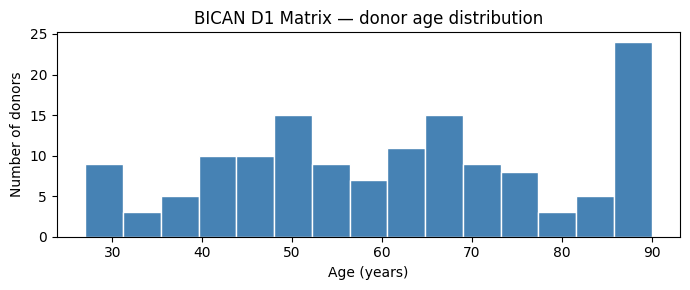

In [18]:
# Keep one row per donor (all cells from the same donor share the same age)
donor_ages = bican.obs.drop_duplicates(SAMPLE_VARIABLE)[AGE].astype(float)

# Histogram of donor ages — sanity check on the cohort demographics
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(donor_ages, bins=15, color="steelblue", edgecolor="white")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of donors")
ax.set_title("BICAN D1 Matrix — donor age distribution")
plt.tight_layout()
plt.show()

### Flag fi you want to run analyss wiht age permutation

In [19]:
# Set PERMUTE_AGE = True to shuffle donor ages before any analysis.
PERMUTE_AGE = False

if PERMUTE_AGE:

    # Get one age value per donor (same value repeated for all cells of that donor)
    donor_age_series = (
        bican.obs
        .drop_duplicates(SAMPLE_VARIABLE)
        .set_index(SAMPLE_VARIABLE)[AGE]
        .astype(float)
    )

    # Shuffle the age values across donors (each donor gets a different donor's real age)
    shuffled_values = donor_age_series.sample(frac=1, random_state=42).values

    # Build a donor_id -> shuffled_age mapping
    permuted_age_map = pd.Series(shuffled_values, index=donor_age_series.index)

    # Overwrite the age column in .obs — all cells from the same donor get the same shuffled age
    bican.obs[AGE] = bican.obs[SAMPLE_VARIABLE].map(permuted_age_map)

    print("WARNING: PERMUTATION MODE active — donor ages are shuffled. This is a null control.")
    print(bican.obs.drop_duplicates(SAMPLE_VARIABLE)[[SAMPLE_VARIABLE, AGE]].head(10))

else:
    print("Standard mode — real donor ages used.")

Standard mode — real donor ages used.


### Chekc if a zone is overrepreseted wiht age

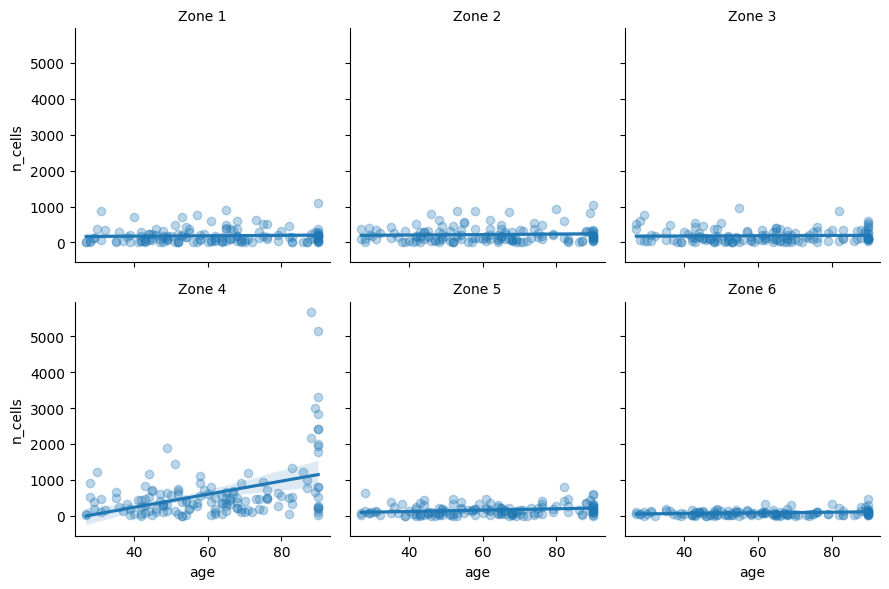

In [20]:
# Check if cells per zone per donor correlates with age
cells_per_zone_donor = (
    bican.obs
    .groupby([SAMPLE_VARIABLE, ZONE_COL], observed=True)
    .size()
    .reset_index(name="n_cells")
    .merge(bican.obs[[SAMPLE_VARIABLE, AGE]].drop_duplicates(), on=SAMPLE_VARIABLE)
)

import seaborn as sns
g = sns.lmplot(data=cells_per_zone_donor, x=AGE, y="n_cells",
               col=ZONE_COL, col_wrap=3, height=3, scatter_kws={"alpha": 0.3})
g.set_titles("Zone {col_name}")
plt.show()


# Define Young (Q1) and Old (Q4) donors

In [ ]:
# Build a one-row-per-donor table with just the age column
donor_meta = (
    bican.obs
    .drop_duplicates(SAMPLE_VARIABLE)   # one row per donor
    .set_index(SAMPLE_VARIABLE)         # donor_id becomes the index
    [[AGE]]                             # keep only the age column
    .astype(float)
)

# Age cutoffs: 25th percentile (upper bound for Young) and 75th (lower bound for Old)
q25 = donor_meta[AGE].quantile(0.25)
q75 = donor_meta[AGE].quantile(0.75)

# Young = bottom quartile (Q1);  Old = top quartile (Q4)
# ATTNETION Q2/Q3 donors are excluded here but included in Nebula with continuous age
young_donors = donor_meta[donor_meta[AGE] <= q25].index.tolist()
old_donors   = donor_meta[donor_meta[AGE] >= q75].index.tolist()

print(f"Young (age <= {q25:.0f}): n = {len(young_donors)}")
print(f"Old   (age >= {q75:.0f}): n = {len(old_donors)}")

Young (age <= 47): n = 37
Old   (age >= 76): n = 36


# Zone filtering for Y/O donors
Each donor has cells spread across up to 6 spatial zones.
Zones with < MIN_CELLS_PER_ZONE cells give unreliable DR estimates, so we remove those cells.

If a donor ends up with 0 valid zones after filtering, they are implicitly absent from the DR dict
and simply do not contribute to any (zone, group) mean_DR computation — no special handling needed.

In [ ]:
# Combine young and old donor IDs into a single list
yo_donors = young_donors + old_donors

# Subset the full AnnData to Y/O donors only — DR is computed only on these
bican_yo = bican[bican.obs[SAMPLE_VARIABLE].isin(yo_donors)].copy()

# Count how many cells each (donor, zone) pair has
cells_per_pair = (
    bican_yo.obs
    .groupby([SAMPLE_VARIABLE, ZONE_COL], observed=True)  # one row per (donor, zone) combination
    .size()
    .reset_index(name="n_cells")
)

# Keep only (donor, zone) pairs with enough cells for a reliable DR estimate
valid_pairs = cells_per_pair[cells_per_pair["n_cells"] >= MIN_CELLS_PER_ZONE]

# Build a set 
valid_set = set(zip(valid_pairs[SAMPLE_VARIABLE], valid_pairs[ZONE_COL]))

# Create a boolean Series: True for each cell whose (donor, zone) pair is valid
pair_labels = list(zip(bican_yo.obs[SAMPLE_VARIABLE], bican_yo.obs[ZONE_COL]))
keep_mask   = pd.Series(pair_labels).isin(valid_set).values

# Drop cells from sparse (donor, zone) pairs
bican_yo = bican_yo[keep_mask].copy()

# Report coverage: how many zones each donor retains after filtering
# Donors with 0 valid zones are simply absent from bican_yo — no special handling needed
n_zones_per_donor = bican_yo.obs.groupby(SAMPLE_VARIABLE, observed=True)[ZONE_COL].nunique()
print(f"Valid (donor, zone) pairs : {len(valid_set)}")
print(f"Zones per donor  —  min: {n_zones_per_donor.min()}  mean: {n_zones_per_donor.mean():.1f}  max: {n_zones_per_donor.max()}")

Valid (donor, zone) pairs : 361
Zones per donor  —  min: 1  mean: 5.0  max: 6


# Compute DR per (donor, zone)
DR = detection rate = fraction of cells in a (donor, zone) pair that express a gene (count > 0).
Each donor contributes one DR array per zone it has valid cells in (1 to 6 values per donor).

In [9]:
# Gene names in the same order as columns in the count matrix
gene_names = bican_yo.var_names.tolist()

# Result dictionary: (donor, zone) -> numpy array of shape (n_genes,) with DR values in [0, 1]
dr_per_pair = {}

# Loop over every Y/O donor present in the filtered AnnData
for donor in bican_yo.obs[SAMPLE_VARIABLE].unique():

    # Boolean mask selecting all cells from this donor
    is_this_donor = bican_yo.obs[SAMPLE_VARIABLE] == donor

    # Get the zones that have valid cells for this donor
    zones_for_donor = bican_yo.obs.loc[is_this_donor, ZONE_COL].unique()

    for zone in zones_for_donor:

        # Boolean mask selecting cells from this specific (donor, zone) pair
        is_this_pair = is_this_donor & (bican_yo.obs[ZONE_COL] == zone)

        # Extract the count matrix for these cells
        X = bican_yo[is_this_pair].X

        # Convert from sparse to dense if needed (arithmetic requires dense arrays)
        if sp.issparse(X):
            X = X.toarray()

        # Detection rate: for each gene, the fraction of cells where count > 0
        dr = (X > 0).mean(axis=0)   # shape: (n_genes,)

        # Store the DR vector for this (donor, zone) pair
        dr_per_pair[(donor, zone)] = dr

print(f"Computed DR for {len(dr_per_pair)} (donor, zone) pairs")

Computed DR for 361 (donor, zone) pairs


# Find G: union of lowly expressed genes across all (zone x YO) combinations

For each of the 12 combinations (6 zones x 2 age groups Y/O):
  1. Average DR across donors in that group that have valid cells in that zone
  2. Flag genes where mean_DR < DR_THR as 'lowly expressed' in this combination

G = union across all 12 combinations.

Taking the union (rather than intersection) is the point:
- Whole-striatum derepressed genes appear in multiple zones -> captured
- Zone-specific derepressed genes appear only in one zone -> also captured
- No zone-specific signal is lost, and we get a single unified candidate list.

In [10]:
# Sorted list of zones present in the data: [1, 2, 3, 4, 5, 6]
zones = sorted(bican_yo.obs[ZONE_COL].unique())

# Running union of lowly-expressed genes across all (zone, group) combinations
G_genes = set()

for zone in zones:
    for group in ["Y", "O"]:

        # Select donors belonging to this age group
        donors_in_group = young_donors if group == "Y" else old_donors

        # Collect DR arrays for donors that have valid cells in this zone
        # (donors with no valid cells in this zone are simply skipped)
        dr_list = [dr_per_pair[(donor, zone)]
                   for donor in donors_in_group
                   if (donor, zone) in dr_per_pair]

        # Skip this combination if no donor has cells in this zone
        if len(dr_list) == 0:
            print(f"  Zone {zone}, {group}: 0 valid donors — skipping")
            continue

        # Average DR across donors — shape: (n_genes,)
        mean_dr = np.mean(dr_list, axis=0)

        # Flag genes where the average DR is below the threshold as "lowly expressed"
        low_genes = {gene_names[i] for i, dr in enumerate(mean_dr) if dr < DR_THR}

        # Add these genes to the running union (duplicates ignored automatically)
        G_genes.update(low_genes)

        print(f"  Zone {zone}, {group}: {len(dr_list):2d} donors — {len(low_genes):5d} lowly expressed genes")

# Sort for reproducibility
G = sorted(G_genes)
print(f"\nG = {len(G)} candidate genes (union across all 12 zone × YO combinations)")

  Zone 1, Y: 29 donors —  5887 lowly expressed genes
  Zone 1, O: 27 donors —  5795 lowly expressed genes
  Zone 2, Y: 32 donors —  5754 lowly expressed genes
  Zone 2, O: 31 donors —  5821 lowly expressed genes
  Zone 3, Y: 28 donors —  5590 lowly expressed genes
  Zone 3, O: 34 donors —  5696 lowly expressed genes
  Zone 4, Y: 33 donors —  5592 lowly expressed genes
  Zone 4, O: 35 donors —  5857 lowly expressed genes
  Zone 5, Y: 29 donors —  5737 lowly expressed genes
  Zone 5, O: 31 donors —  5842 lowly expressed genes
  Zone 6, Y: 25 donors —  5794 lowly expressed genes
  Zone 6, O: 27 donors —  5618 lowly expressed genes

G = 6356 candidate genes (union across all 12 zone × YO combinations)


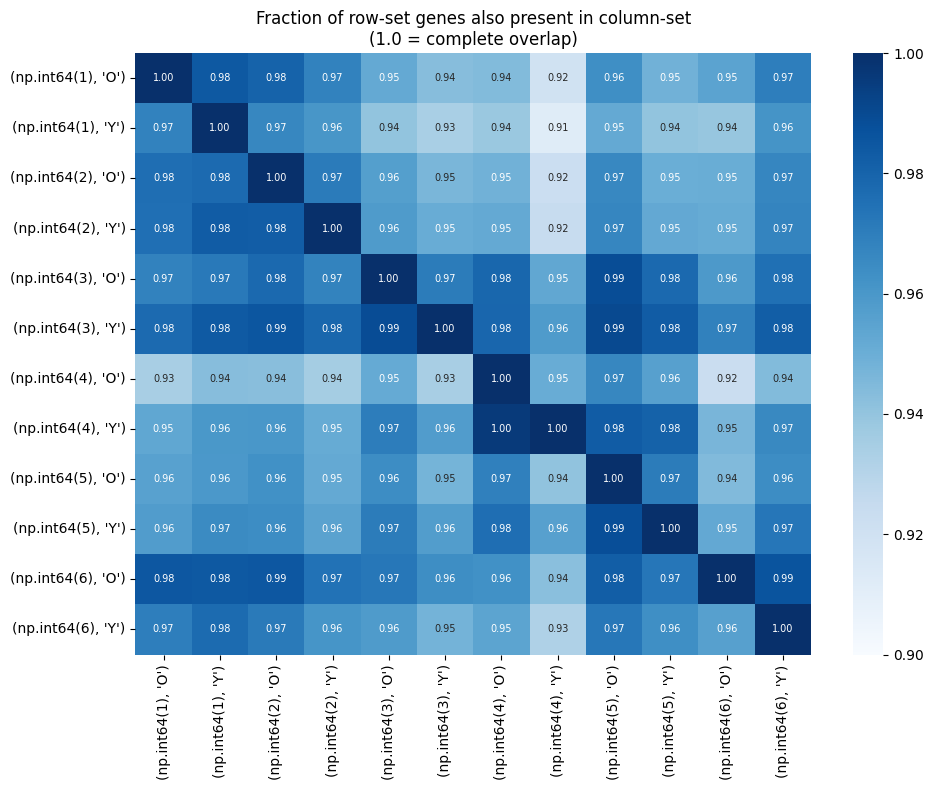

In [11]:
from itertools import product
import seaborn as sns

# Recompute the set of low-DR genes for each (zone, group) combination
# (same logic as the G-building cell above — needed to inspect per-combination membership)
low_sets = {}
for zone in zones:
    for group in ["Y", "O"]:
        donors_in_group = young_donors if group == "Y" else old_donors
        dr_list = [dr_per_pair[(donor, zone)]
                   for donor in donors_in_group
                   if (donor, zone) in dr_per_pair]
        if len(dr_list) == 0:
            continue
        mean_dr = np.mean(dr_list, axis=0)
        # Store the low-DR gene set for this (zone, group) key
        low_sets[(zone, group)] = {gene_names[i] for i, dr in enumerate(mean_dr) if dr < DR_THR}

# Build an overlap matrix: entry (A, B) = fraction of set A that is also in set B
# Values near 1.0 mean the two combinations share almost the same lowly-expressed genes
keys       = sorted(low_sets)
key_labels = [str(k) for k in keys]

overlap = pd.DataFrame(index=key_labels, columns=key_labels, dtype=float)

for key_a, key_b in product(keys, repeat=2):
    set_a = low_sets[key_a]
    set_b = low_sets[key_b]
    # Avoid division by zero if a set is empty
    overlap.loc[str(key_a), str(key_b)] = len(set_a & set_b) / len(set_a) if len(set_a) > 0 else 0.0

# Heatmap: near-1 everywhere → G is dominated by genes that are lowly expressed in ALL combinations
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(overlap.astype(float), annot=True, fmt=".2f", cmap="Blues",
            vmin=0.9, vmax=1.0, ax=ax, annot_kws={"size": 7})
ax.set_title("Fraction of row-set genes also present in column-set\n(1.0 = complete overlap)")
plt.tight_layout()
plt.show()

# Prepare adata for Nebula (ALL donors, only G genes)
Nebula is run on all BICAN donors — not just Y/O — to use the full continuous age range.

Nebula accepts only flat numeric covariates, so we manually encode the zone x age interaction:
- zone_2 ... zone_6: dummy variables (1 if cell is in that zone)  — zone_1 = reference
- age_x_zone_2 ... age_x_zone_6: age * zone_k interaction terms

This is equivalent to the R formula:  ~ age * zone  (but pre-encoded as numeric columns)
Full Nebula model:  count ~ age + zone_2..6 + age:zone_2..6 + sex + PC1-5
                           + offset(log(total_counts)) + (1 | donor_id)

In [12]:
# Subset to ALL donors (not just Y/O) but only the G candidate genes
# Nebula uses the full continuous age range — not just the extremes used to define G
bican_nebula = bican[:, G].copy()

# Ensure .X holds raw integer counts (required by Nebula)
bican_nebula.X = bican_nebula.layers["counts"].copy()

# Zones other than the reference zone need dummy columns and interaction columns
non_ref_zones = [z for z in sorted(bican_nebula.obs[ZONE_COL].unique()) if z != REF_ZONE]

# Nebula accepts only flat numeric covariates — no formula syntax — so we pre-encode manually
for zone in non_ref_zones:

    # Zone dummy: 1 if this cell is in this zone, 0 otherwise (main zone effect)
    bican_nebula.obs[f"zone_{zone}"] = (bican_nebula.obs[ZONE_COL] == zone).astype(float)

    # Age × zone interaction: carries the donor's age for cells in this zone, 0 elsewhere
    # This encodes how much the age slope changes in zone k relative to the reference zone
    bican_nebula.obs[f"age_x_zone_{zone}"] = (
        bican_nebula.obs[AGE] * bican_nebula.obs[f"zone_{zone}"]
    )

# Encode sex as 0/1 numeric if it is stored as a string ('M'/'F')
if bican_nebula.obs[SEX_COL].dtype == object:
    bican_nebula.obs[SEX_COL] = (bican_nebula.obs[SEX_COL] == "M").astype(float)  # 1 = Male, 0 = Female

# Assemble the full covariate list (all must be numeric columns already in .obs)
ZONE_DUMMIES      = [f"zone_{z}"       for z in non_ref_zones]  # zone main effects
ZONE_INTERACTIONS = [f"age_x_zone_{z}" for z in non_ref_zones]  # age × zone interactions
NEBULA_COVARIATES = [AGE, *ZONE_DUMMIES, *ZONE_INTERACTIONS, SEX_COL, *PC_COLS]

# Drop any cell with a missing value in any covariate — Nebula cannot handle NaN
nan_mask = bican_nebula.obs[NEBULA_COVARIATES].isna().any(axis=1)
print(f"Dropping {nan_mask.sum()} cells with NaN covariates")
bican_nebula = bican_nebula[~nan_mask].copy()

print(bican_nebula)
print(f"\nNebula covariates ({len(NEBULA_COVARIATES)}): {NEBULA_COVARIATES}")

Dropping 0 cells with NaN covariates
AnnData object with n_obs × n_vars = 206571 × 6356
    obs: 'prefix', 'cell_barcode', 'expression_doublet', 'num_genic_reads', 'num_transcripts', 'num_genes', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_intronic', 'pct_mt', 'frac_contamination', 'donor_external_id', 'biobank', 'cohort', 'age', 'race', 'pmi_hr', 'sex', 'eur_adj', 'afr_adj', 'nat_adj', 'eas_adj', 'sas_adj', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'toxicology_group', 'toxicology_report_complete', 'toxicology_compounds_detected', 'hbcac_status', 'experiment', 'scpred_cortex_class', 'scpred_cortex_class_max_prob', 'scpred_cortex_gaba_sub_class', 'scpred_cortex_gaba_sub_class_max_prob', 'scpred_cortex_glut_sub_class', 'scpred_cortex_glut_sub_class_max_prob', 'scpred_caudate_class', 'scpred_caudate_class_max_prob', 'scpred_caudate_spn_di', 'scpred_caudate_spn_di_max_prob', 'scpred_caudate_spn_en', 'scpred_caudate_spn_en_max_prob', 'scpred_caudate_spn_mp', 'scpred

# Run Nebula

In [13]:
# Cast count matrix to integer dtype — Nebula requires integer counts, not floats
bican_nebula.X = bican_nebula.layers["counts"].astype(int).copy()

In [14]:
# Output path for the Seurat .qs file (the format the Nebula R script reads)
QS_PATH = f"{SAVE_FOLDER}/bican_nebula.qs"

# Create a temporary directory to hold intermediate files for R conversion
tmp_dir = tempfile.mkdtemp(dir="/tmp")

# Write the count matrix and metadata in a format the R script can ingest
preprocessing.save_files_for_R_conversion(bican_nebula, tmp_dir)

# Build the Seurat .qs object from those files
preprocessing.build_qs_from_python_files(
    tmp_dir,
    saving_path     = QS_PATH,
    contrast_var    = None,   # no binary group contrast — age is continuous
    reference_level = None,
)

# Run Nebula across gene chunks in parallel and collect the result path
nebula_result_path = DEG.run_nebula_parallel_script(
    path_qs            = QS_PATH,
    path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
    id_col             = SAMPLE_VARIABLE,    # column grouping cells by donor (random effect)
    covs               = NEBULA_COVARIATES,  # flat list of pre-encoded numeric covariates
    offset_col         = LIBRARY_SIZE_COL,   # Nebula takes log(this) as the library-size offset
    n_folds            = 40,                 # split genes into 40 chunks (reduces RAM per job)
    n_cores            = 40,                 # run 40 chunks in parallel
    save_tmp           = False,
)

2026-04-24 17:06:26 | [WARNING] R callback write-console: Loading required package: SeuratObject
  
2026-04-24 17:06:26 | [WARNING] R callback write-console: Loading required package: sp
  
2026-04-24 17:06:27 | [WARNING] R callback write-console: 
Attaching package: ‘SeuratObject’

  
2026-04-24 17:06:27 | [WARNING] R callback write-console: The following objects are masked from ‘package:base’:

    %||%, intersect, t

  



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

2026-04-24 17:06:31 | [WARNING] R callback write-console: 
Attaching package: ‘Seurat’

  
2026-04-24 17:06:31 | [WARNING] R callback write-console: The following object is masked from ‘package:base’:

    %||%

  
2026-04-24 17:06:31 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  


[1] "Creating Seurat object..."


2026-04-24 17:06:55 | [WARNING] R callback write-console: Warning:  
2026-04-24 17:06:55 | [WARNING] R callback write-console:  Data is of class dgTMatrix. Coercing to dgCMatrix.
  


[1] "Saving Seurat object as .qs..."
cmd list: ['bash', '/home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh', '--path', '/home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula/bican_nebula.qs', '--id-col', 'donor_id', '--offset-col', 'total_counts', '--n-folds', '40', '--n-cores', '40', '--save-tmp', '0']
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula/bican_nebula.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/_old/bican_d1matrix_nebula/bican_nebula.qs --id-col donor_id --offset-col total_counts --n-folds 40 --n-cores 40 --save-tmp 0 --covs age,zone_2,zone_3,zone_4,zone_5,zone_6,age_x_zone_2,age_x_zone_3,age_x_zone_4,age_x_zone_5,age_x_zone_6,sex,PC1,PC2,PC3,PC4,PC5
[INFO]

# Save and inspect results

In [4]:
RESULTS_CSV = f"{SAVE_FOLDER}/nebula_results.csv"


In [ ]:
# Read the Nebula result file in R, extract the summary table, and save it as CSV
ro.r(f'''
    library(qs)
    obj <- qread("{nebula_result_path}")   # load the Nebula result object (list with $summary, etc.)
    df  <- obj$summary                     # one row per gene, one column per covariate beta / p-value
    write.csv(df, "{RESULTS_CSV}", row.names=FALSE)
''')


Results: 4650 genes


,logFC_(Intercept),logFC_age,logFC_zone_2,logFC_zone_3,logFC_zone_4,logFC_zone_5,logFC_zone_6,logFC_age_x_zone_2,logFC_age_x_zone_3,logFC_age_x_zone_4,...,p_age_x_zone_5,p_age_x_zone_6,p_sex,p_PC1,p_PC2,p_PC3,p_PC4,p_PC5,gene_id,gene
0,-14.663714,-0.000047,0.269577,0.131425,0.489321,0.509462,-0.098096,-0.000599,0.002433,0.000373,...,0.293044,0.495222,0.734299,0.181128,0.817359,0.001845,0.809063,0.132874,1,A1CF
1,-15.358424,0.002616,0.565609,0.424381,1.010807,0.236198,0.257279,-0.003708,0.001985,0.000514,...,0.270791,0.962559,0.234437,0.629355,0.793367,0.524303,0.972313,0.466536,3,A2MP1
2,-14.437388,-0.002391,0.161856,-0.325669,-0.090319,-0.170730,-0.132707,-0.002934,0.004588,0.001923,...,0.245317,0.692065,0.763480,0.053693,0.482127,0.000408,0.031112,0.796448,4,A3GALT2
3,-16.752655,0.003432,0.321077,0.308323,0.527614,0.294818,-0.850663,-0.002994,-0.002568,-0.002892,...,0.649631,0.414505,0.212178,0.223118,0.536015,0.011515,0.195986,0.196113,7,AADAC
4,-15.892157,0.000920,-0.264816,0.010330,-0.150818,-0.232699,0.278884,0.004458,-0.001721,0.000035,...,0.707682,0.369001,0.377089,0.881027,0.311123,0.311776,0.226381,0.510456,10,AADACL4


In [5]:
# Load the CSV into a pandas DataFrame for all downstream analysis
df = pd.read_csv(RESULTS_CSV)
print(f"Results: {len(df)} genes")
display(df.head())

Results: 4737 genes


,logFC_(Intercept),logFC_age,logFC_zone_2,logFC_zone_3,logFC_zone_4,logFC_zone_5,logFC_zone_6,logFC_age_x_zone_2,logFC_age_x_zone_3,logFC_age_x_zone_4,...,p_age_x_zone_5,p_age_x_zone_6,p_sex,p_PC1,p_PC2,p_PC3,p_PC4,p_PC5,gene_id,gene
0,-14.644286,0.007957,0.883128,0.812201,0.434584,0.997215,0.117485,-0.010295,-0.008325,0.000776,...,0.000176,0.785577,0.429352,0.213156,0.604034,0.001649,0.841116,0.099574,1,A1CF
1,-15.336885,0.004600,0.827110,0.802825,0.776143,0.481695,0.224157,-0.007776,-0.003999,0.003743,...,0.819944,0.950954,0.553840,0.651733,0.844920,0.475187,0.961664,0.477066,3,A2MP1
2,-14.420527,0.003193,0.035988,-0.197570,0.000038,-0.043068,-0.249651,-0.000778,0.002611,0.000474,...,0.773886,0.281044,0.436651,0.054054,0.614073,0.000292,0.035360,0.913818,4,A3GALT2
3,-16.730269,0.011691,0.366955,0.960977,0.562836,0.931625,-0.232468,-0.003522,-0.012905,-0.003748,...,0.063581,0.879693,0.512321,0.311711,0.714062,0.006756,0.210266,0.207431,7,AADAC
4,-15.876741,0.001996,0.109238,-0.424765,-0.496134,-0.366611,-0.689495,-0.001693,0.005254,0.004831,...,0.416454,0.040711,0.950736,0.627242,0.073146,0.266410,0.132240,0.454538,10,AADACL4


In [13]:
# Quick ranking: which genes have the largest positive age coefficient?
# Higher logFC_age = expression increases most strongly with age in reference zone

from statsmodels.stats.multitest import multipletests

df_sig = df[["gene", "logFC_age", "p_age"]].dropna().copy()

df_sig["fdr_age"] = multipletests(df_sig["p_age"], method="fdr_bh")[1]

df_sig["log2FC_50yr"] = df_sig["logFC_age"] * 50 / np.log(2)

df_sig = df_sig[df_sig["fdr_age"] < 0.05].sort_values("logFC_age", ascending=False).head(30)

df_sig

,gene,logFC_age,p_age,fdr_age,log2FC_50yr
4276,TMEM26-AS1,0.047099,6.228211e-12,6.146465e-10,3.397470
1752,GRP,0.046346,4.480697e-07,1.494723e-05,3.343149
3378,PTGER2,0.043909,3.980585e-33,2.357004e-30,3.167334
1203,DUX4,0.038839,7.592924e-12,7.250265e-10,2.801656
2810,NPY2R-AS1,0.037975,3.022801e-03,1.706170e-02,2.739300
1355,FAM110C,0.037837,1.076939e-36,1.700487e-33,2.729383
2809,NPY2R,0.036858,3.216531e-04,3.065736e-03,2.658746
3906,SNCG,0.035122,7.921749e-07,2.405469e-05,2.533545
1179,DRGX,0.034001,2.794996e-06,7.080158e-05,2.452668
4275,TMEM26,0.033257,6.389599e-14,8.407647e-12,2.399011


,covariate,n_genes,median,pct_pos,wilcoxon_p
0,logFC_age (signal),4737,0.00374,76.2%,< 2.2e-16 (underflow)
1,logFC_sex (control),4737,0.00577,53.3%,1.16e-02
2,logFC_age_x_zone_2 (control),4737,-0.00223,29.3%,1.00e+00


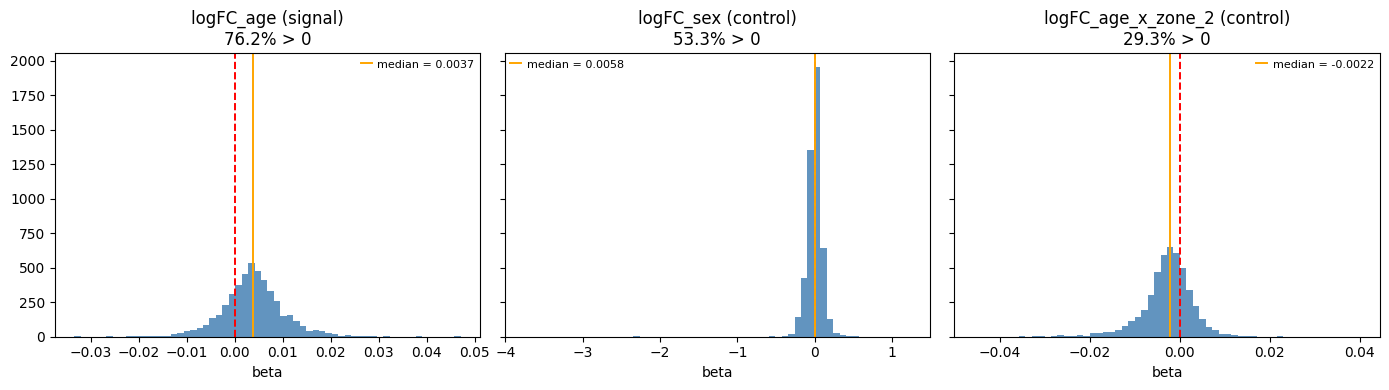

In [12]:
from scipy.stats import wilcoxon

# logFC_sex and logFC_age_x_zone_2 were not used to define G → expected symmetric around 0.
# If only logFC_age is right-skewed, the age signal is real, not a Nebula/selection artifact.
CONTROLS = {
    f"logFC_{AGE} (signal)":         f"logFC_{AGE}",
    "logFC_sex (control)":           "logFC_sex",
    "logFC_age_x_zone_2 (control)":  "logFC_age_x_zone_2",
}

rows = []
for label, col in CONTROLS.items():
    vals = df[col].dropna()
    _, pval = wilcoxon(vals, alternative="greater")
    rows.append({
        "covariate": label,
        "n_genes":   len(vals),
        "median":    round(vals.median(), 5),
        "pct_pos":   f"{(vals > 0).mean() * 100:.1f}%",
        "wilcoxon_p": f"{pval:.2e}" if pval > 0 else "< 2.2e-16  (underflow)",
    })

display(pd.DataFrame(rows))

# Visual comparison: three histograms on the same x-axis
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (label, col) in zip(axes, CONTROLS.items()):
    vals = df[col].dropna()
    ax.hist(vals, bins=60, color="steelblue", edgecolor="none", alpha=0.85)
    ax.axvline(0,             color="red",    linestyle="--", lw=1.4)
    ax.axvline(vals.median(), color="orange", linestyle="-",  lw=1.4,
               label=f"median = {vals.median():.4f}")
    ax.set_title(f"{label}\n{(vals > 0).mean()*100:.1f}% > 0")
    ax.set_xlabel("beta")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# Plot beta_age distribution
If de-repression is active across G genes, the distribution of age coefficients should be right-skewed:
more genes increase expression with age (beta > 0) than decrease.
A symmetric distribution centred at 0 would indicate no systematic age effect.

Note: beta_age is the age slope in the REFERENCE zone (zone REF_ZONE).
The interaction terms (age_x_zone_k) capture how this slope differs in each other zone.

Age beta column(s) found: ['logFC_age']


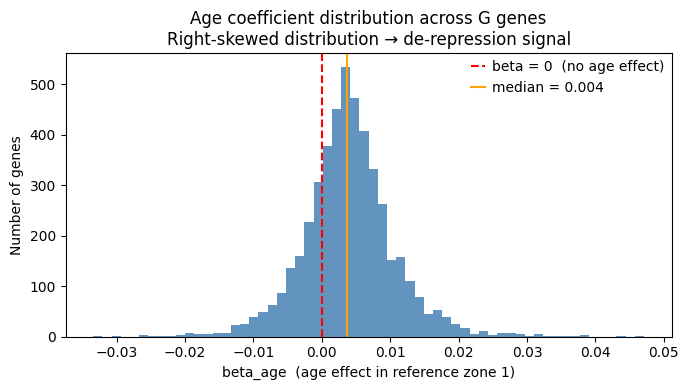

Mean   beta_age    : 0.0039
Median beta_age    : 0.0037
% genes with beta > 0 : 76.2%


In [7]:
# Find the column holding the main age coefficient
# Nebula names it logFC_<covariate_name>; we exclude interaction terms (which contain "zone")
age_beta_col = [c for c in df.columns if AGE in c and "logFC" in c and "zone" not in c]
print("Age beta column(s) found:", age_beta_col)

# Drop NaN rows — some genes may have failed to converge in Nebula
beta_age = df[age_beta_col[0]].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(beta_age, bins=60, color="steelblue", edgecolor="none", alpha=0.85)

# Vertical line at 0: this is where genes with no age effect cluster
ax.axvline(0, color="red", linestyle="--", lw=1.5, label="beta = 0  (no age effect)")

# Vertical line at the median: if positive, the typical gene in G increases with age
ax.axvline(beta_age.median(), color="orange", linestyle="-", lw=1.5,
           label=f"median = {beta_age.median():.3f}")

ax.set_xlabel(f"beta_age  (age effect in reference zone {REF_ZONE})")
ax.set_ylabel("Number of genes")
ax.set_title("Age coefficient distribution across G genes\n"
             "Right-skewed distribution → de-repression signal")
ax.legend()
plt.tight_layout()
plt.show()

# Key summary statistics
print(f"Mean   beta_age    : {beta_age.mean():.4f}")
print(f"Median beta_age    : {beta_age.median():.4f}")
print(f"% genes with beta > 0 : {(beta_age > 0).mean() * 100:.1f}%")

In [11]:
from scipy.stats import wilcoxon
stat, pval = wilcoxon(beta_age, alternative='greater')
print(f"Wilcoxon p-value (H0: median beta = 0): {pval:.2e}")


Wilcoxon p-value (H0: median beta = 0): 0.00e+00


# Per-zone age slopes
The `beta_age` above is the age effect **only in the reference zone (zone 1)**.
The interaction terms tell us how each other zone's slope differs from zone 1:
- Zone 1 slope = `logFC_age`
- Zone k slope = `logFC_age` + `logFC_age_x_zone_k`

In [8]:
# Identify the column holding the main age coefficient (slope in the reference zone)
age_main_col = [c for c in df.columns if AGE in c and "logFC" in c and "zone" not in c][0]
print("Age main column:", age_main_col)

# Reference zone slope = logFC_age directly
per_zone_slopes = {REF_ZONE: df[age_main_col].dropna()}

# For every other zone: total slope = reference slope + interaction delta
# Column names look like "logFC_age_x_zone_3" — extract the zone number with replace()
interaction_cols = [c for c in df.columns if "logFC_age_x_zone_" in c]

for col in interaction_cols:
    # Extract zone number: "logFC_age_x_zone_3" → 3
    zone_id = int(col.replace("logFC_age_x_zone_", ""))
    # Zone k slope = main age slope + interaction term for zone k
    per_zone_slopes[zone_id] = (df[age_main_col] + df[col]).dropna()

# Summary table: one row per zone showing median slope, mean slope, and % genes with positive slope
summary = pd.DataFrame({
    "zone":        sorted(per_zone_slopes),
    "median_beta": [per_zone_slopes[z].median() for z in sorted(per_zone_slopes)],
    "mean_beta":   [per_zone_slopes[z].mean()   for z in sorted(per_zone_slopes)],
    "pct_pos":     [(per_zone_slopes[z] > 0).mean() * 100 for z in sorted(per_zone_slopes)],
})
display(summary)

Age main column: logFC_age


,zone,median_beta,mean_beta,pct_pos
0,1,0.003744,0.003898,76.208571
1,2,0.001395,0.001156,59.805784
2,3,0.003147,0.002792,70.719865
3,4,0.004858,0.004690,82.689466
4,5,0.003595,0.003077,72.429808
5,6,0.003952,0.003748,73.042010


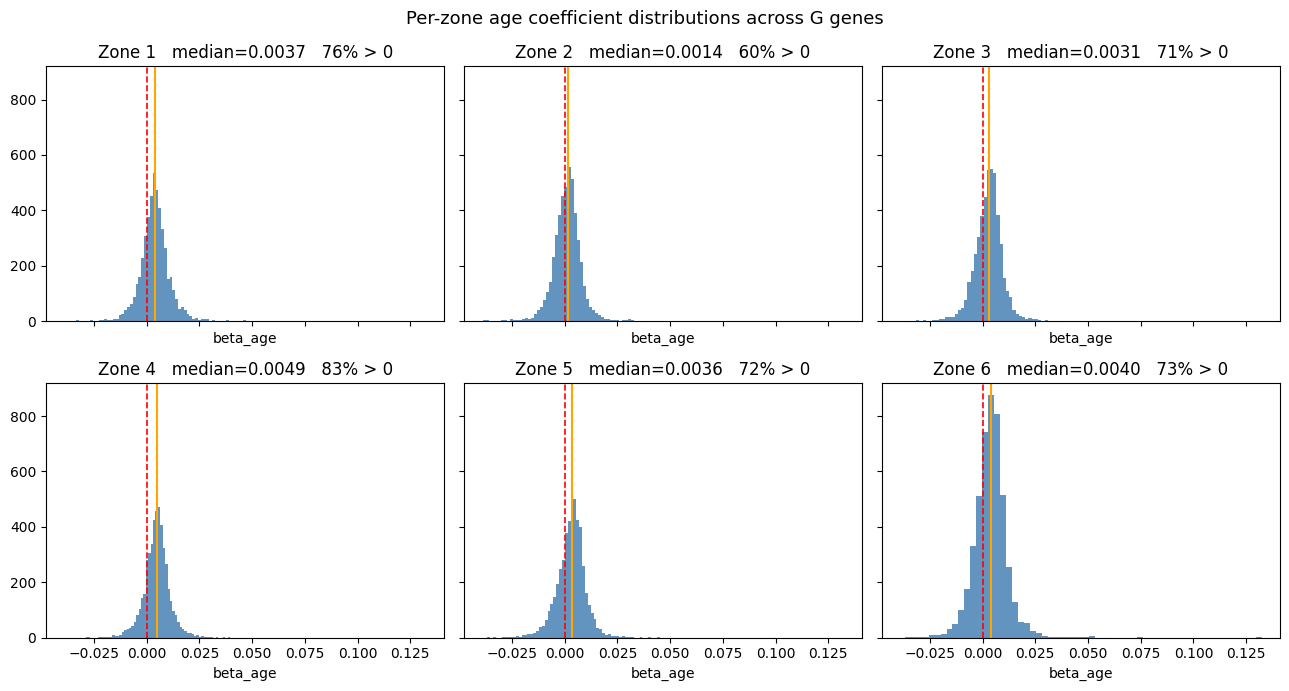

2026-04-30 16:55:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-30 16:55:55 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


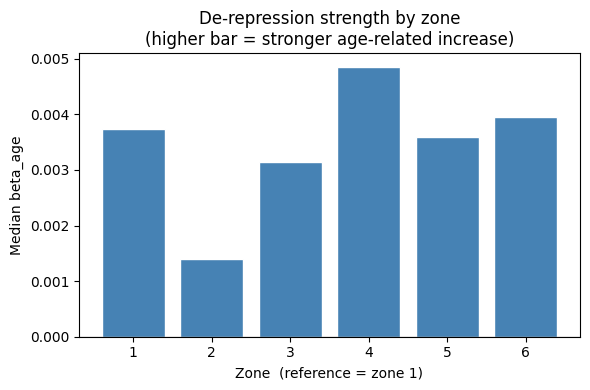

In [9]:
# One subplot per zone: distribution of age coefficients across all G genes
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)

for ax, zone in zip(axes.flatten(), sorted(per_zone_slopes)):
    beta = per_zone_slopes[zone]

    ax.hist(beta, bins=60, color="steelblue", edgecolor="none", alpha=0.85)

    # Red dashed line at 0: null hypothesis (no age effect in this zone)
    ax.axvline(0, color="red", linestyle="--", lw=1.2)

    # Orange line at the median: typical age slope in this zone
    ax.axvline(beta.median(), color="orange", linestyle="-", lw=1.5)

    pct_pos = (beta > 0).mean() * 100
    ax.set_title(f"Zone {zone}   median={beta.median():.4f}   {pct_pos:.0f}% > 0")
    ax.set_xlabel("beta_age")

fig.suptitle("Per-zone age coefficient distributions across G genes", fontsize=13)
plt.tight_layout()
plt.show()

# Bar chart: median beta per zone — at a glance which zones show the strongest de-repression
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([str(z) for z in summary["zone"]], summary["median_beta"],
       color="steelblue", edgecolor="white")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel(f"Zone  (reference = zone {REF_ZONE})")
ax.set_ylabel("Median beta_age")
ax.set_title("De-repression strength by zone\n(higher bar = stronger age-related increase)")
plt.tight_layout()
plt.show()

# Polycomb enrichment
Are polycomb / PRC2 target genes enriched among the most de-repressed G genes?

derepressed == beta_age  NEGATIVE --> os my universe must be only genes wiht pos beta 
dont care og gene lowly in Old (passed the first selectetion) but hihg in Y --> not derepression

Strategy: **Mann-Whitney U test** — tests whether polycomb targets have stochastically larger
`beta_age` values than non-targets. No significance cutoff required; works on the full distribution.


,category,n_in_geneset,n_in_G,median_beta,pct_pos,pval,fdr,sig
0,supp_table_3_PRC2_paper,179,40,0.007042,100.0,0.029296,0.032812,*
1,death_promoting_silenced_by_prc2,9,3,0.014760,100.0,0.032812,0.032812,*


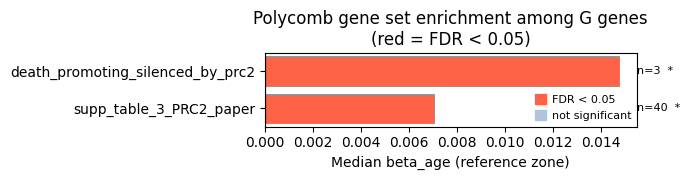

In [10]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Known Polycomb / PRC2 target gene sets — sourced from published ChIP-seq / supplementary tables
GENE_SETS = {
    "supp_table_3_PRC2_paper": [
        'POU4F2', 'TWIST1', 'ALDH1A2', 'IRX5', 'CALCR', 'CDKN2A', 'SKOR1', 'PITX2',
        'HOXC8', 'WT1', 'SFMBT2', 'POU4F1', 'TAL1', 'PNMT', 'DSP', 'CDHR1', 'SPP1',
        'HOXD8', 'NKX6-1', 'HOXC4', 'RIPK4', 'LECT1', 'PYGL', 'DMRT3', 'TFAP2C',
        'FST', 'GPR101', 'RUNX3', 'ONECUT2', 'BARX1', 'AMN', 'TMEM30B', 'IRX3',
        'CCND1', 'IRX2', 'S100A10', 'FAM196B', 'LGALS3', 'SIX6', 'TBX2', 'CD44',
        'ASB4', 'SCARF2', 'VGLL2', 'BNC2', 'LYPD1', 'GATA3', 'OTOF', 'HOXD10',
        'HOXA9', 'HOXC10', 'SLC6A5', 'LBX1', 'HOXA5', 'TBX20', 'HAND2', 'HOXD9',
        'HOXB7', 'HOXB8', 'MNX1', 'DMRTA2', 'FOXF1', 'SIM2', 'GATA6', 'SIX2',
        'LUM', 'GATA2', 'PMAIP1', 'HOXA10', 'BHLHE22', 'FOXD1', 'PITX1', 'PAX1',
        'HMX1', 'TBX3', 'FOXA1', 'EBF3', 'HOXB13', 'EN1', 'HOXD13', 'LHX5',
        'HOXA7', 'HOXC5', 'NEUROD1', 'TFAP2A', 'HOXB5', 'SHOX2', 'TFAP2B',
        'NEUROD2', 'TLX1', 'TNNT2', 'SULT1A1', 'VAX2', 'HOXD11', 'CDKN1A',
        'NEUROG2', 'EOMES', 'PLIN4', 'TPBG', 'SSTR3', 'DLK1', 'PRDM8', 'HOXA4',
        'NRN1', 'VSX2', 'GFI1', 'ADCYAP1', 'LHX1', 'NKX3-1', 'LHX9', 'ZIC2',
        'MATN2', 'HOXB3', 'KRT1', 'IGFBP3', 'FBN1', 'OVGP1', 'CDKN2B', 'HOXB2',
        'HEYL', 'GSTA3', 'NKX2-5', 'TSHZ2', 'FOXD2', 'ALDOC', 'HMGCS2', 'DLX4',
        'SIX1', 'GRP', 'COL23A1', 'CIRBP', 'HOXB6', 'LMX1B', 'CBX4', 'RPRM',
        'PAX3', 'MFSD4', 'GPR50', 'SFRP2', 'ISLR', 'ASB5', 'MYCL1', 'SDC1',
        'GATA4', 'BEND5', 'FXYD7', 'FOXL2', 'ONECUT1', 'DAB1', 'ZFAND4', 'RPP25',
        'CLDN3', 'SLC6A7', 'COLEC11', 'S100A8', 'COL6A2', 'CYBRD1', 'MMD',
        'GNA13', 'ALX1', 'NTF3', 'GRHL1', 'HOXA3', 'FHOD3', 'GREB1L', 'PAMR1',
        'CPA6', 'DMRT2', 'CPNE6', 'BID', 'C1QTNF1', 'KAZALD1', 'HOXD3', 'SLCO4A1',
        'S100A9', 'MYO5B', 'ANXA1', 'ACY3', 'SH2B2',
    ],
    "death_promoting_silenced_by_prc2": [
        "PMAIP1", "BID", "CDKN2A", "CDKN2B", "CCND1", "WT1", "IGFBP3", "TP73", "CDKN1A",
    ],
    # "hox": [
    #     "HOXA3", "HOXA4", "HOXA5", "HOXA7", "HOXA9", "HOXA10",
    #     "HOXB2", "HOXB3", "HOXB5", "HOXB6", "HOXB7", "HOXB8", "HOXB13",
    #     "HOXC4", "HOXC5", "HOXC8", "HOXC10",
    #     "HOXD3", "HOXD8", "HOXD9", "HOXD10", "HOXD11", "HOXD13",
    # ],
}

# Working table: gene name + main age coefficient, NaN rows removed
df_betas = df[["gene", age_main_col]].dropna().copy()


# ONLY POS BETAS
df_betas = df_betas[df_betas[age_main_col] > 0].copy()


# Minimum number of genes from a set that must be present in G to run the test
MIN_IN_G = 3

# ── Mann-Whitney U test for each gene set ──────────────────────────────────────
# H1 (one-sided): genes in the set have stochastically larger beta_age than the background
records = []

for category, gene_list in GENE_SETS.items():

    # Keep only genes from this set that are present in the Nebula results
    genes_in_G = [g for g in gene_list if g in df_betas["gene"].values]

    # Skip if too few genes are in G for a meaningful test
    if len(genes_in_G) < MIN_IN_G:
        continue

    # Beta values for this gene set and for all other genes (background)
    beta_set        = df_betas.loc[df_betas["gene"].isin(genes_in_G), age_main_col]
    beta_background = df_betas.loc[~df_betas["gene"].isin(genes_in_G), age_main_col]

    # One-sided Mann-Whitney: is the set stochastically greater than the background?
    _, pval = mannwhitneyu(beta_set, beta_background, alternative="greater")

    records.append({
        "category":     category,
        "n_in_geneset": len(gene_list),     # total genes in the curated set
        "n_in_G":       len(genes_in_G),    # how many of those are in our G
        "median_beta":  beta_set.median(),
        "pct_pos":      (beta_set > 0).mean() * 100,
        "pval":         pval,
    })

# Collect results and apply Benjamini-Hochberg FDR correction across gene sets
results = pd.DataFrame(records)
_, results["fdr"], _, _ = multipletests(results["pval"], method="fdr_bh")
results = results.sort_values("pval").reset_index(drop=True)

# Add a significance label for quick visual reading
results["sig"] = results["fdr"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)
display(results)

# ── Forest-style horizontal bar chart ─────────────────────────────────────────
plot_df = results.sort_values("median_beta", ascending=True).reset_index(drop=True)

# Red bars = FDR < 0.05 (enriched); blue bars = not significant
colors = ["tomato" if fdr < 0.05 else "lightsteelblue" for fdr in plot_df["fdr"]]

fig, ax = plt.subplots(figsize=(7, 0.45 * len(plot_df) + 1))
ax.barh(plot_df["category"], plot_df["median_beta"], color=colors, edgecolor="grey", linewidth=0.5)
ax.axvline(0, color="black", lw=0.8)

# Annotate each bar with gene count and significance stars
for i, row in plot_df.iterrows():
    ax.text(plot_df["median_beta"].max() * 1.05, i,
            f"n={row['n_in_G']}  {row['sig']}", va="center", fontsize=8)

ax.set_xlabel("Median beta_age (reference zone)")
ax.set_title("Polycomb gene set enrichment among G genes\n(red = FDR < 0.05)")

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color="tomato", label="FDR < 0.05"),
             Patch(color="lightsteelblue", label="not significant")],
    loc="lower right", fontsize=8,
)
plt.tight_layout()
plt.show()